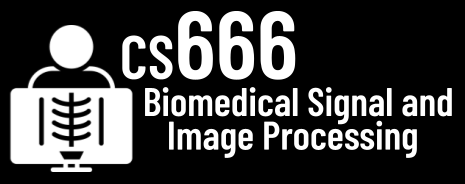
#Assignment 6

In [ ]:
# NAME: SangHyuk Kim

In [ ]:
# In this assignment, we will visualize and explore a CT scan!

In [ ]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [ ]:
# we are using pydicom, so lets install it!
!pip install pydicom

     |████████████████████████████████| 1.9MB 8.5MB/s 


**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [ ]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [1]:
!wget https://cs666.org/data/ct.zip

--2026-05-06 21:01:06--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to cs666.org (cs666.org)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  27.6MB/s    in 0.2s    

2026-05-06 21:01:07 (27.6 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [ ]:
# Then use the following snippet to extract the data.

In [2]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [4]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

import os
dcm_files = [f for f in os.listdir('./ct') if f.endswith('.dcm')]
print("Number of slices:", len(dcm_files))

Number of slices: 220


#### 220 Slices

In [ ]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

<img src="assignment6_imgs/3dvol_acs.png" width="70%">

In [ ]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

<img src="assignment6_imgs/bone.png" width="70%">

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [ ]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [ ]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY

In [9]:
from pydicom import dcmread
import numpy as np

dcm_files = sorted([f for f in os.listdir('./ct') if f.endswith('.dcm')])

ref_dcm = dcmread(os.path.join('./ct', dcm_files[0]))
dims = (int(ref_dcm.Rows), int(ref_dcm.Columns), len(dcm_files))

ct_volume = np.zeros(dims, dtype=ref_dcm.pixel_array.dtype)

for i, filename in enumerate(dcm_files):
    ct_volume[:, :, i] = dcmread(os.path.join('./ct', filename)).pixel_array

In [ ]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

interactive(children=(IntSlider(value=109, description='z', max=219), Output()), _dom_classes=('widget-interac…

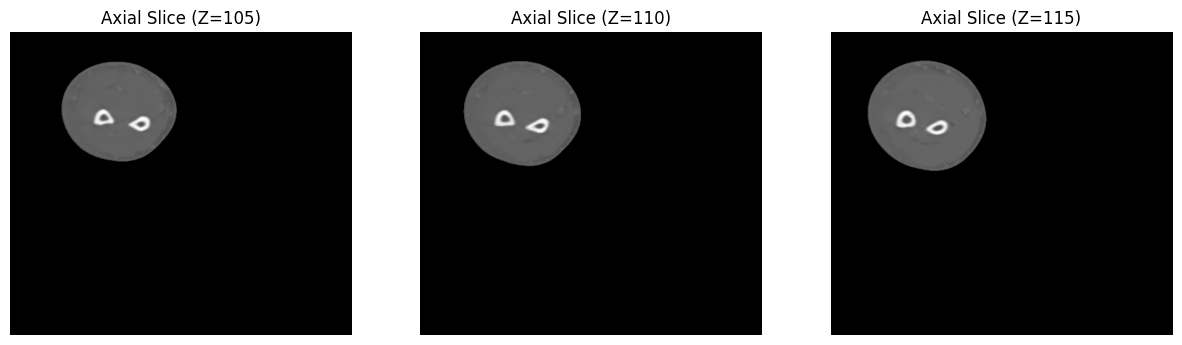

In [29]:
# TODO: YOUR CODE FOR AXIAL
from ipywidgets import interact
import matplotlib.pyplot as plt

def show_axial(z):
    plt.figure(figsize=(6, 6))
    plt.imshow(ct_volume[:, :, z], cmap='gray')
    plt.title(f'Axial Slice (Z={z})')
    plt.axis('off')
    plt.show()

# Creates a slider to scroll through all slices along the Z-axis
interact(show_axial, z=(0, ct_volume.shape[2] - 1))

# Static visualization for GitHub compatibility
mid_z = ct_volume.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, offset in enumerate([-5, 0, 5]):
    slice_idx = max(0, min(ct_volume.shape[2] - 1, mid_z + offset))
    axes[i].imshow(ct_volume[:, :, slice_idx], cmap='gray')
    axes[i].set_title(f'Axial Slice (Z={slice_idx})')
    axes[i].axis('off')
    
plt.show()

interactive(children=(IntSlider(value=255, description='x', max=511), Output()), _dom_classes=('widget-interac…

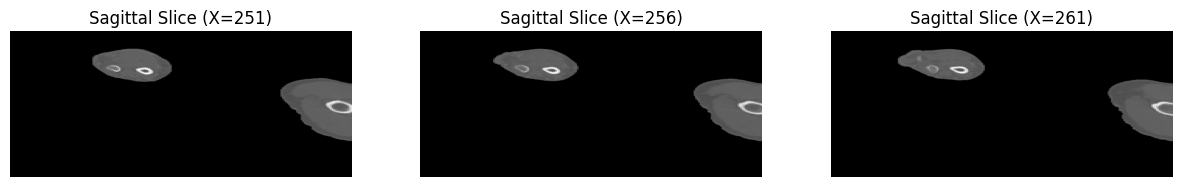

In [ ]:
# TODO: YOUR CODE FOR SAGITTAL

pixel_spacing = ref_dcm.PixelSpacing 
slice_thickness = ref_dcm.SliceThickness

sagittal_aspect = pixel_spacing[0] / slice_thickness
coronal_aspect = pixel_spacing[1] / slice_thickness

def show_sagittal(x):
    # We can add a reasonable figsize back in now that the math is fixed
    plt.figure(figsize=(8, 8))
    plt.imshow(ct_volume[:, x, :], cmap='gray', aspect=sagittal_aspect)
    plt.title(f'Sagittal Slice (X={x})')
    plt.axis('off')
    plt.show()

interact(show_sagittal, x=(0, ct_volume.shape[1] - 1))

# Static visualization for GitHub compatibility
mid_x = ct_volume.shape[1] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, offset in enumerate([-5, 0, 5]):
    slice_idx = max(0, min(ct_volume.shape[1] - 1, mid_x + offset))
    axes[i].imshow(ct_volume[:, slice_idx, :], cmap='gray', aspect=sagittal_aspect)
    axes[i].set_title(f'Sagittal Slice (X={slice_idx})')
    axes[i].axis('off')

plt.show()

interactive(children=(IntSlider(value=226, description='y', max=453), Output()), _dom_classes=('widget-interac…

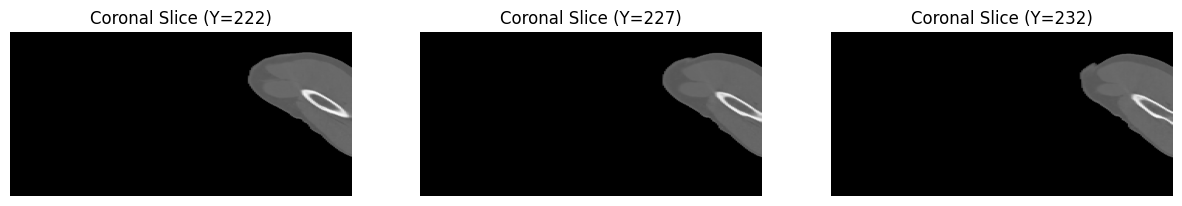

In [ ]:
# TODO: YOUR CODE FOR CORONAL
def show_coronal(y):
    plt.figure(figsize=(8, 8))
    plt.imshow(ct_volume[y, :, :], cmap='gray', aspect=coronal_aspect)
    plt.title(f'Coronal Slice (Y={y})')
    plt.axis('off')
    plt.show()

interact(show_coronal, y=(0, ct_volume.shape[0] - 1))

# Static visualization for GitHub compatibility
mid_y = ct_volume.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, offset in enumerate([-5, 0, 5]):
    slice_idx = max(0, min(ct_volume.shape[0] - 1, mid_y + offset))
    axes[i].imshow(ct_volume[slice_idx, :, :], cmap='gray', aspect=coronal_aspect)
    axes[i].set_title(f'Coronal Slice (Y={slice_idx})')
    axes[i].axis('off')

plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

interactive(children=(IntSlider(value=110, description='Slice Z:', max=219), IntSlider(value=410, description=…

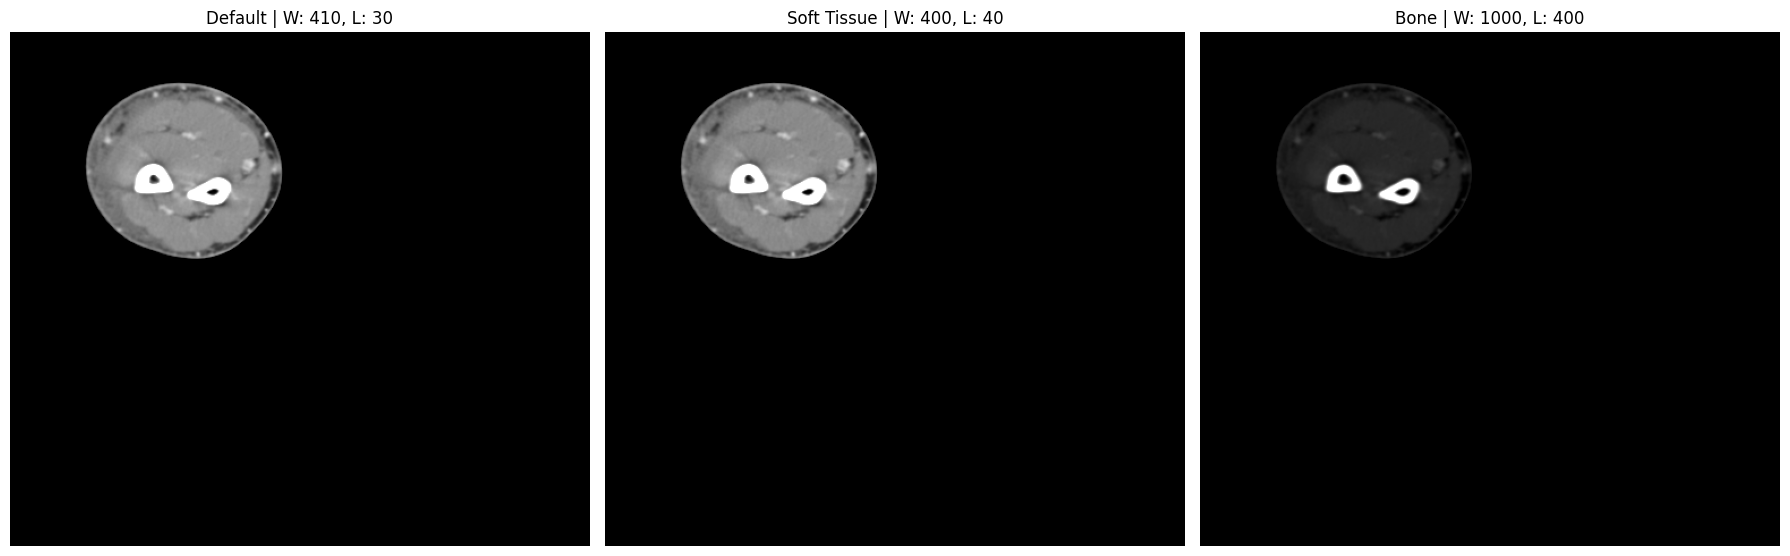

In [32]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

# Convert the entire 3D volume to Hounsfield Units (HU)
intercept = ref_dcm.RescaleIntercept
slope = ref_dcm.RescaleSlope
hu_volume = (ct_volume * slope) + intercept

# Extract DICOM tags. Handle potential MultiValue arrays.
level = ref_dcm.WindowCenter
window = ref_dcm.WindowWidth

# Pydicom sometimes returns a MultiValue list, so we grab the first element
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

def explore_window_level_multi(z, window, level):
    vmin = level - (window / 2)
    vmax = level + (window / 2)
    
    # Create a 1x3 grid for multiple slices
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # We will look at the current slice (z), one 5 slices below, and one 5 slices above
    offsets = [-5, 0, 5] 
    
    for i, offset in enumerate(offsets):
        # We use max() and min() to ensure we don't accidentally ask for a slice 
        # outside the boundaries of the CT volume when scrolling near the ends
        slice_idx = max(0, min(hu_volume.shape[2] - 1, z + offset))
        
        axes[i].imshow(hu_volume[:, :, slice_idx], cmap='gray', vmin=vmin, vmax=vmax)
        axes[i].set_title(f'Axial (Z={slice_idx}) | W: {window}, L: {level}')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

interact(explore_window_level_multi, 
         z=IntSlider(min=0, max=hu_volume.shape[2]-1, value=hu_volume.shape[2]//2, description='Slice Z:'),
         window=IntSlider(min=50, max=3000, step=50, value=int(window), description='Window:'),
         level=IntSlider(min=-1000, max=1000, step=50, value=int(level), description='Level:'))


# Static Window/Level Demonstration for GitHub compatibility
configs = [
    {"title": "Default", "level": level, "window": window},
    {"title": "Soft Tissue", "level": 40, "window": 400},
    {"title": "Bone", "level": 400, "window": 1000}
]

mid_z = ct_volume.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, config in enumerate(configs):
    hu_min = config["level"] - (config["window"] / 2)
    hu_max = config["level"] + (config["window"] / 2)
    
    raw_vmin = (hu_min - intercept) / slope
    raw_vmax = (hu_max - intercept) / slope
    
    axes[i].imshow(ct_volume[:, :, mid_z], cmap='gray', vmin=raw_vmin, vmax=raw_vmax)
    axes[i].set_title(f'{config["title"]} | W: {config["window"]}, L: {config["level"]}')
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()

In [ ]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

In [25]:
# TODO: YOUR CODE
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

level_tag = ref_dcm[0x0028, 0x1050].value
window_tag = ref_dcm[0x0028, 0x1051].value
intercept = float(ref_dcm[0x0028, 0x1052].value)
slope = float(ref_dcm[0x0028, 0x1053].value)

level = float(level_tag[0]) if type(level_tag).__name__ == 'MultiValue' else float(level_tag)
window = float(window_tag[0]) if type(window_tag).__name__ == 'MultiValue' else float(window_tag)

print(f"Default Level (HU): {level}")
print(f"Default Window (HU): {window}")
print(f"Rescale Intercept: {intercept}")
print(f"Rescale Slope: {slope}")

def explore_window_level(z, window_hu, level_hu):
    hu_min = level_hu - (window_hu / 2)
    hu_max = level_hu + (window_hu / 2)
    
    raw_vmin = (hu_min - intercept) / slope
    raw_vmax = (hu_max - intercept) / slope
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    offsets = [-5, 0, 5] 
    
    for i, offset in enumerate(offsets):
        slice_idx = max(0, min(ct_volume.shape[2] - 1, z + offset))
        axes[i].imshow(ct_volume[:, :, slice_idx], cmap='gray', vmin=raw_vmin, vmax=raw_vmax)
        axes[i].set_title(f'Axial (Z={slice_idx}) | W: {window_hu}, L: {level_hu}')
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

interact(explore_window_level, 
         z=IntSlider(min=0, max=ct_volume.shape[2]-1, value=ct_volume.shape[2]//2, description='Slice Z:'),
         window_hu=IntSlider(min=50, max=3000, step=50, value=int(window), description='Window:'),
         level_hu=IntSlider(min=-1000, max=1000, step=50, value=int(level), description='Level:'))

Default Level (HU): 30.0
Default Window (HU): 410.0
Rescale Intercept: -1024.0
Rescale Slope: 1.0


interactive(children=(IntSlider(value=110, description='Slice Z:', max=219), IntSlider(value=410, description=…

<function __main__.explore_window_level(z, window_hu, level_hu)>

In [ ]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

In [ ]:
# TODO: YOUR CODE

<img src="assignment6_imgs/window_level.png" width="70%">

In [ ]:
# Which values make sense and why?

In [ ]:
# TODO: YOUR ANSWER

#### A Level of +40 HU and a Window of 400 HU are optimal for this view. The +40 HU level centers the grayscale on typical soft tissue radiodensities, while the narrow 400 HU window stretches the monitor's 256 shades of gray strictly across this limited range. This maximizes contrast, clearly differentiating dark subcutaneous fat from lighter muscle. Dense bone exceeds the +240 HU upper limit and clips to pure white, perfectly isolating the soft tissues.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [ ]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

In [ ]:
# TODO: YOUR CODE TO SEGMENT FAT
# Fat HU range: -120 to -40
fat_lower_raw = (-120 - intercept) / slope
fat_upper_raw = (-40 - intercept) / slope

fat_mask = ((ct_volume >= fat_lower_raw) & (ct_volume <= fat_upper_raw)).astype(np.int16)

def show_fat(z):
    plt.imshow(fat_mask[:, :, z], cmap='gray')
    plt.title(f"Fat Mask (Z={z})")
    plt.axis('off')
    plt.show()

interact(show_fat, z=(0, fat_mask.shape[2] - 1));

interactive(children=(IntSlider(value=109, description='z', max=219), Output()), _dom_classes=('widget-interac…

In [ ]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE
# Soft Tissue HU range: 20 to 80
soft_lower_raw = (20 - intercept) / slope
soft_upper_raw = (80 - intercept) / slope

soft_mask = ((ct_volume >= soft_lower_raw) & (ct_volume <= soft_upper_raw)).astype(np.int16)

def show_soft_tissue(z):
    plt.imshow(soft_mask[:, :, z], cmap='gray')
    plt.title(f"Soft Tissue Mask (Z={z})")
    plt.axis('off')
    plt.show()

interact(show_soft_tissue, z=(0, soft_mask.shape[2] - 1));

interactive(children=(IntSlider(value=109, description='z', max=219), Output()), _dom_classes=('widget-interac…

In [28]:
# TODO: YOUR CODE TO SEGMENT BONES
# Bone HU threshold: > 300
bone_lower_raw = (300 - intercept) / slope

bone_mask = (ct_volume >= bone_lower_raw).astype(np.int16)

def show_bones(z):
    plt.imshow(bone_mask[:, :, z], cmap='gray')
    plt.title(f"Bone Mask (Z={z})")
    plt.axis('off')
    plt.show()

interact(show_bones, z=(0, bone_mask.shape[2] - 1));

interactive(children=(IntSlider(value=109, description='z', max=219), Output()), _dom_classes=('widget-interac…

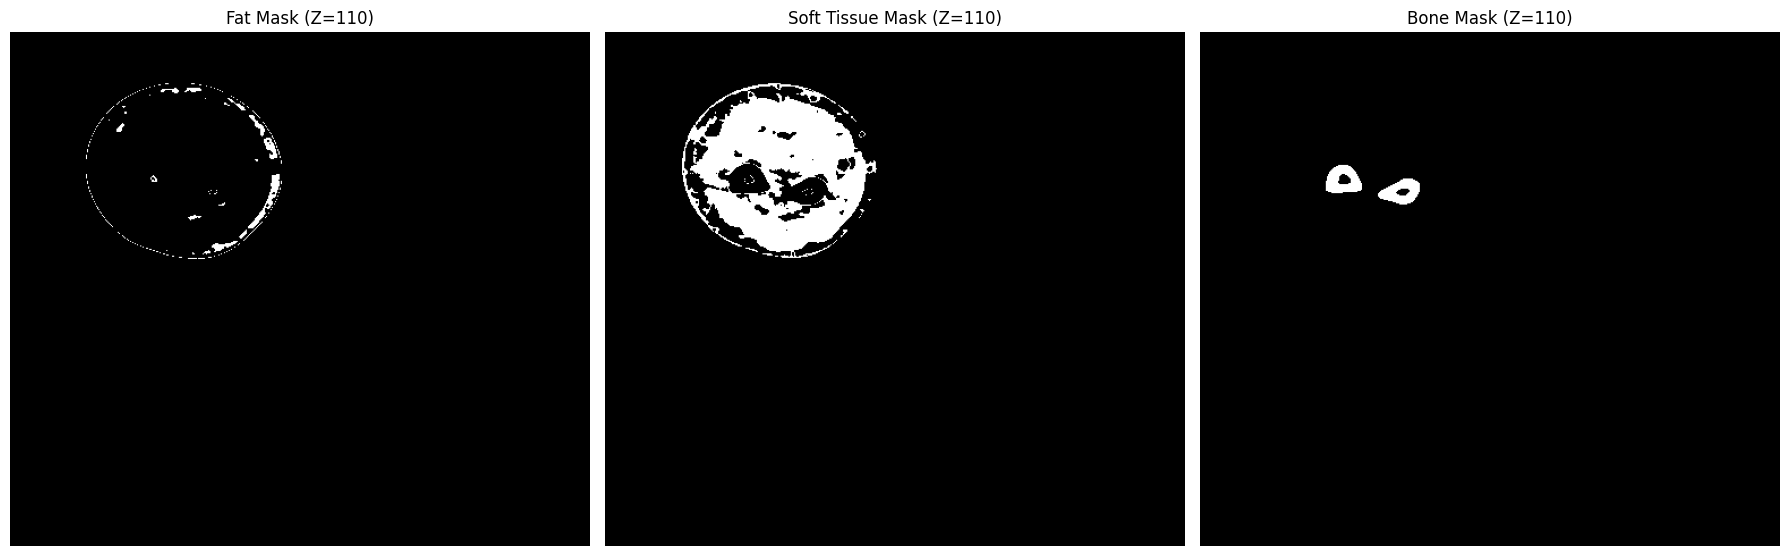

In [33]:
# Static segmentations for GitHub compatibility
mid_z = ct_volume.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(fat_mask[:, :, mid_z], cmap='gray')
axes[0].set_title(f"Fat Mask (Z={mid_z})")
axes[0].axis('off')

axes[1].imshow(soft_mask[:, :, mid_z], cmap='gray')
axes[1].set_title(f"Soft Tissue Mask (Z={mid_z})")
axes[1].axis('off')

axes[2].imshow(bone_mask[:, :, mid_z], cmap='gray')
axes[2].set_title(f"Bone Mask (Z={mid_z})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Are the segmentations good?

In [ ]:
# TODO: YOUR ANSWER

#### Yes, the segmentations are working well given the simplicity of the approach. Because CT scanners are physically calibrated to water (0 HU) and air (-1000 HU), biological tissues fall into highly predictable, objective numerical bands. While it lacks the fine boundary precision of a convolutional framework like a U-Net, HU thresholding can separate primary anatomical zones (fat vs. bone vs. muscle) with consistency with zero training data.

In [ ]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""